# Домашняя работа 4.

## Чтение данных и прочее.

Будем использовать этот [корпус](https://www.csc.kth.se/cvap/actions/), но так как для колаба выгружать все видосы и в цикле загружать их кадры через cv2 - это смертеподобно, то сначала мы локально соберём всё в один .npz файл, в котором будут айди, матрица кадров и само действие. Это сделано для того, чтобы один раз считать всю нужную информацию из одного файла, а не пробегаться по облаку, что крайне неэффективно. Вот код для этого действия:

In [ ]:
import os
import cv2
import numpy as np

def pack_kth_from_subfolders_to_npz(root_dir, output_filename="kth_data.npz", T_in=80, T_out=40, frame_size=64):
    total_frames = T_in + T_out
    X_list, Y_list = [], []
    person_ids = []
    labels = []

    print(f"Сканируем корневую директорию '{root_dir}' и все её подпапки...")

    for root, dirs, files in os.walk(root_dir):
        video_files = [f for f in files if f.lower().endswith(('.avi', '.mp4'))]

        for video_name in video_files:
            parts = video_name.split('_')
            try:
                p_id = int(parts[0].lower().replace('person', ''))
                label = parts[1]
            except Exception:
                continue

            if p_id > 9:
                continue

            video_path = os.path.join(root, video_name)
            cap = cv2.VideoCapture(video_path)
            frames = []

            while len(frames) < total_frames:
                ret, frame = cap.read()
                if not ret:
                    break

                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                resized = cv2.resize(gray, (frame_size, frame_size))
                frames.append(resized.flatten() / 255.0)

            cap.release()

            if len(frames) > 0:
                while len(frames) < total_frames:
                    frames.append(np.zeros(frame_size * frame_size))

                frames = np.array(frames, dtype=np.float32)
                X_list.append(frames[:T_in])
                Y_list.append(frames[T_in:])
                person_ids.append(p_id)
                labels.append(label)

    if len(X_list) == 0:
        print("ОШИБКА: Видеофайлы так и не были найдены. Проверьте правильность пути к корневой папке!")
        return

    print(f"\nОбработка завершена. Найдено и запаковано роликов: {len(X_list)}")

    np.savez_compressed(
        output_filename,
        X=np.array(X_list, dtype=np.float32),
        Y=np.array(Y_list, dtype=np.float32),
        ids=np.array(person_ids, dtype=np.int32),
        labels=np.array(labels, dtype=object)
    )
    print(f"Успешно создано! Файл: {output_filename}")


pack_kth_from_subfolders_to_npz(r'C:\study\шифт_2курс\dl\141', output_filename='kth_data_test.npz')


Сканируем корневую директорию 'C:\study\шифт_2курс\dl\141' и все её подпапки...

Обработка завершена. Найдено и запаковано роликов: 216
Успешно создано! Файл: kth_data_test.npz


То есть таким образом мы имеем $T = 80$ кадров, которые проходят через нашу сеть, и 40 кадров, которые нам нужно предсказать.

In [1]:
import numpy as np

train = np.load('kth_data_train.npz', allow_pickle = True)
X_train, y_train, ids_train, labels_train = train['X'], train['Y'], train['ids'], train['labels']
X_train.shape, y_train.shape

((383, 80, 4096), (383, 40, 4096))

## Модель!

In [2]:
!pip install xlstm

In [3]:
import torch.nn as nn
import torch
from torch.optim import Adam

from xlstm import sLSTMBlock, mLSTMBlock, sLSTMBlockConfig, sLSTMLayerConfig, mLSTMBlockConfig, mLSTMLayerConfig, xLSTMBlockStackConfig, xLSTMBlockStack

class xLSTMV_Vid_Pred(nn.Module):
  def __init__(self, T = 80, x_t_dim = 4096, T_pred = 40):
    super(xLSTMV_Vid_Pred, self).__init__()
    self.context_length = 80
    self.embedding_dim = 4096
    self.in_proj = nn.Linear(in_features = x_t_dim, out_features = 256)
    cfg = xLSTMBlockStackConfig(
      mlstm_block = mLSTMBlockConfig(mlstm = mLSTMLayerConfig(conv1d_kernel_size=4,
                                     num_heads = 8,
                                     qkv_proj_blocksize=4)),
      slstm_block = sLSTMBlockConfig(slstm = sLSTMLayerConfig(conv1d_kernel_size=4,
                                     backend="vanilla")),

      context_length = T,
      num_blocks = 12,
      embedding_dim = 256,
      slstm_at = [4, 9, 10, 11]
    )

    self.xlstm = xLSTMBlockStack(cfg).to('cuda')
    self.out_proj = nn.Linear(in_features = 256, out_features = 40 * x_t_dim)

  def forward(self, X):
    X_in = self.in_proj(X)
    hidden_states = self.xlstm(X_in)
    out = self.out_proj(hidden_states[:, -1, :])
    return out





## Обучение

In [49]:
model = xLSTMV_Vid_Pred().to('cuda')
loss = nn.L1Loss()
num_epochs = 40
optim = Adam(model.parameters(), lr = 0.0001)

model.train()
for epoch in range(num_epochs):
  loss_arr = []
  for i in range(0, X_train.shape[0], 10):
    X_batch = torch.from_numpy(X_train[i : i + 10]).to('cuda')
    y_batch = torch.from_numpy(y_train[i : i + 10]).to('cuda')

    optim.zero_grad()
    y_hat = model(X_batch)
    y_hat = y_hat.view(-1, 40, 4096)
    res = loss(y_hat, y_batch)
    res.backward()
    optim.step()
    loss_arr.append(res.item())

  print(f'Epoch : {epoch + 1} / {num_epochs}, Loss: {sum(loss_arr) / len(loss_arr)}')

Epoch : 1 / 40, Loss: 0.452107425683584
Epoch : 2 / 40, Loss: 0.1858722223685338
Epoch : 3 / 40, Loss: 0.13783802569676668
Epoch : 4 / 40, Loss: 0.10979178223090294
Epoch : 5 / 40, Loss: 0.0984235711586781
Epoch : 6 / 40, Loss: 0.07591667561194836
Epoch : 7 / 40, Loss: 0.07112853343670185
Epoch : 8 / 40, Loss: 0.067823670231379
Epoch : 9 / 40, Loss: 0.06930049890891099
Epoch : 10 / 40, Loss: 0.06336991651318012
Epoch : 11 / 40, Loss: 0.06652846922859168
Epoch : 12 / 40, Loss: 0.0688307295816067
Epoch : 13 / 40, Loss: 0.07457229485496497
Epoch : 14 / 40, Loss: 0.06782459935698754
Epoch : 15 / 40, Loss: 0.07278700297077496
Epoch : 16 / 40, Loss: 0.0657221790498648
Epoch : 17 / 40, Loss: 0.06337147120099801
Epoch : 18 / 40, Loss: 0.06557436631276058
Epoch : 19 / 40, Loss: 0.06373085864843467
Epoch : 20 / 40, Loss: 0.06640019668982579
Epoch : 21 / 40, Loss: 0.06441311538219452
Epoch : 22 / 40, Loss: 0.06568993484744659
Epoch : 23 / 40, Loss: 0.06400143479307492
Epoch : 24 / 40, Loss: 0.064

## Валидация.

In [50]:
model.eval()
test = np.load('kth_data_test.npz', allow_pickle = True)
X_test, y_test, ids_train, labels_train = test['X'], test['Y'], test['ids'], test['labels']

X_test.shape

(216, 80, 4096)

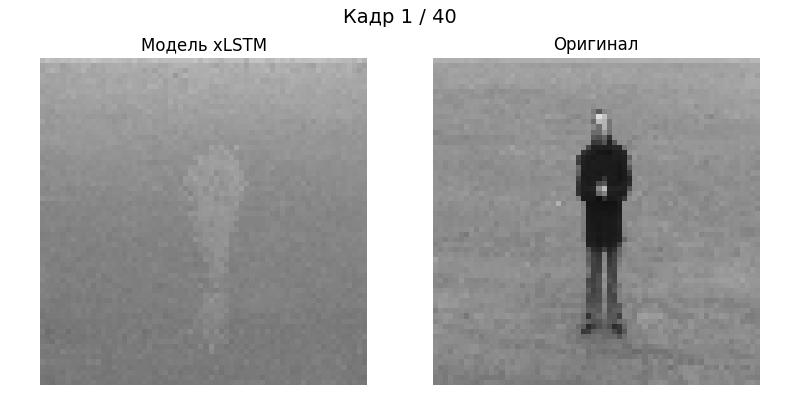

In [52]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image, display

test_input = torch.from_numpy(X_test[42]).to('cuda').unsqueeze(0)

out_test = model(test_input)
out_video = out_test.view(40, 4096)


pred_frames = out_video.detach().cpu().numpy().reshape(40, 64, 64)
true_frames = y_test[42].reshape(40, 64, 64)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle("Сравнение генерации xLSTM и Оригинала", fontsize=14)

ax1.set_title("Модель xLSTM")
ax1.axis('off')
im1 = ax1.imshow(pred_frames[0], cmap='gray', vmin=0, vmax=1)

ax2.set_title("Оригинал")
ax2.axis('off')
im2 = ax2.imshow(true_frames[0], cmap='gray', vmin=0, vmax=1)

plt.tight_layout()

def update(frame_idx):
    im1.set_data(pred_frames[frame_idx])
    im2.set_data(true_frames[frame_idx])
    fig.suptitle(f"Кадр {frame_idx + 1} / 40", fontsize=14)
    return [im1, im2]

ani = animation.FuncAnimation(
    fig, update, frames=40, interval=100, blit=False
)

ani.save("xlstm_comparison.gif", writer="pillow")
plt.close()
display(Image(filename="xlstm_comparison.gif"))


## Выводы.

- **Понимание данных**. Модель состоит из 12 рекуррентных слоёв: 4 x mLSTM - 1 x sLSTM - 4 x mLSTM - 3 x sLSTM. То есть её можно поделить на 3 уровня: нижний, промежуточный и верхний. На нижнем уровне, то есть в первых 4 mLSTM моделируется основная информация о видео, то есть фон, положение человека, основное действие. После этого информация оттуда обрабатывается одним sLSTM, например, извлекается информацию о том, что человек бегает. На промежуточном блоке из 4 mLSTM моделируются уже какие-то более точные признаки, а затем на верхнем слое из 3 sLSTM информация и о грубых, и о точных признаках обрабатывается и моделируются тонкие связи. Однако в нашем случае было несколько проблем: Во-первых, подавать $x_t$ размерности 64x64 - это очень больно, поэтому первым слоем модели идёт линейный, которые проецирует наши вектора в меньшее пространство, а на выходе другим линейным слоем мы проецируем сжатые вектора обратно. Проблема с этим в том, что мы можем терять таким образом много информации, так как сжимаем довольно сильно. Подобная проблема может возникнуть с размерностью скрытых состояний, поэтому, возможно, если взять размерности побольше, то модель сможет сохранить больше информации о данных и связях в них, чем улучшит свою предсказательную способность.
- **Связи между предыдущими шагами и текущим**. В нашем случае модель получала на вход в каждый блок отдельный кадр, то есть в скрытых состояниях каждого рекурретного слоя была информация про всё видео до этого момента включительно с учётом связей между кадрами. Возможно, если бы модели подавались кадры не подряд, а через какие-то промежутки, то она бы эффективнее училась моделировать изменения между кадрами, тогда и предсказания бы улучшились, так как при передаче кадров подряд они зачастую отличаются на шум, что по сути заставляет xLSTM моделировать шум.
- **Влияние метрик**. Начнём с самых очевидных выводов, а именно: как модель подстраивает свои ответы при разных метриках. Опробовано было две: `MSELoss` и `L1Loss`, в первом случае модель предсказывает фон, положение основной фигуры в очень размытом виде, но создаёт вокруг неё театр теней, как будто пытаясь угадать все движения сразу; во втором случае предсказания получаются более шумными, попытки угадать все движения пропадают, зато модель предсказывает положение и вид основной фигуры, хотя сами движения она уже никак не предсказывает. То есть модель в любом случае благодаря своей архитектуре отлично запоминает основные черты видео, но в одном случае пытается предугадать движения, смешивая всё сразу, а в другом не делает никаких предположений, оставляя только основные черты в качестве своего предсказания.
